# 02 — Conversational KPI Agent: End-to-End Demo

Pipeline: **question → structured Query Plan → registry validation →
deterministic calculation → narrated result.** No model computes a number
in this pipeline — a language model's only job (or, here, a small
rule-based parser standing in for one with zero API dependency) is to
produce a structured plan; a separate deterministic layer does the
arithmetic, which is what keeps every answer checkable against the raw
panel.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd

from data_layer import load_roster, build_monthly_panel
from agent import answer_question
from signal_scan import scan_for_signals
import calculation_engine as calc

roster = load_roster("../data/raw/hr_employee_attrition.csv")
result = build_monthly_panel(roster)
panel, months = result.monthly_panel, result.months

## Question-first: snapshot

In [2]:
out = answer_question("What is the TTM voluntary turnover rate for Sales?", panel, months)
print(out["narration"])
out["result"]

TTM voluntary turnover for Sales is 17.1% as of 2025-12.


{'as_of_month': '2025-12',
 'department': 'Sales',
 'TTM': {'rate': np.float64(0.1709),
  'terminations': 67,
  'avg_headcount': np.float64(392.1),
  'months_available': 12}}

## Question-first: comparison (current vs. prior month)

In [3]:
out = answer_question("How does Research & Development's turnover compare TTM vs last month?", panel, months)
print(out["narration"])
out["result"]

Research & Development turnover moved up from 9.7% in 2025-11 to 10.2% in 2025-12 (+0.5% pts).


{'department': 'Research & Development',
 'window': 12,
 'current_month': '2025-12',
 'current': {'rate': np.float64(0.102),
  'terminations': 90,
  'avg_headcount': np.float64(882.5),
  'months_available': 12},
 'baseline_month': '2025-11',
 'baseline': {'rate': np.float64(0.0967),
  'terminations': 85,
  'avg_headcount': np.float64(879.4),
  'months_available': 12},
 'change_in_rate': np.float64(0.0053)}

## Question-first: change-driver (which department moved the company number)

In [4]:
out = answer_question("Which department is driving the change in company-wide turnover?", panel, months)
print(out["narration"])
out["result"]

Sales contributed the most to the company-wide change (+0.53% pts), with its own TTM rate moving +1.84% pts.


,department,headcount_weight,own_rate_change,contribution_to_company_change
0,Sales,0.290,0.0184,0.0053
1,Research & Development,0.669,0.0053,0.0035
2,Human Resources,0.041,0.0003,0.0000


## Guardrail: unrecognized department triggers a clarification, not a guess

In [5]:
out = answer_question("What's the turnover rate for Marketing?", panel, months)
print(out["plan"].warnings)
print(out["narration"])

['No specific department recognized in the question -- defaulting to a company-wide view. Ask about a specific department by name for a scoped answer.']
TTM voluntary turnover for the company overall is 12.3% and T3M is 3.6% as of 2025-12.


## Signal-first: proactive scan across all departments

In [6]:
signals = scan_for_signals(panel, months)
signals

,department,current_ttm_rate,prior_ttm_rate,move,avg_headcount,small_population_warning,flagged
0,Sales,0.1709,0.1525,0.0184,392.1,False,True
1,Research & Development,0.1020,0.0967,0.0053,882.5,False,False
2,Human Resources,0.1280,0.1277,0.0003,54.7,False,False


## Trend view

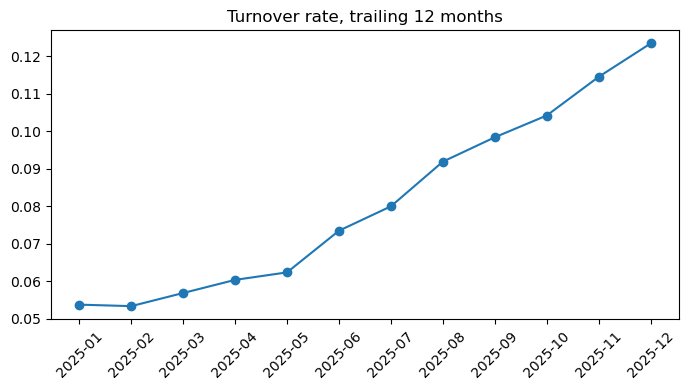

In [7]:
import matplotlib.pyplot as plt

trend_df = calc.trend(panel, out["plan"], months, lookback=12)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(trend_df["month"], trend_df["rate"], marker="o")
ax.set_title("Turnover rate, trailing 12 months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Summary

The same four-stage pipeline (parse → validate → calculate → narrate)
handles snapshot, comparison, change-driver, and trend questions, plus a
proactive signal-scan entry point that routes into the same change-driver
calculation. Registry validation catches an unrecognized department before
any calculation runs, rather than letting a parser's best guess silently
produce a company-wide answer without saying so.